# Lab Assignment - 5

### AutoEncoders

### CS22B1093 ROHAN G

----------------

### Q1 - MNIST dataset compression and reconstruction using PCA and AutoEncoder

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [71]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=60000, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)

train_images, _ = next(iter(train_loader))
test_images, _ = next(iter(test_loader))

train_images = train_images.view(-1, 784).numpy()
test_images = test_images.view(-1, 784).numpy()

print("Train data shape:", train_images.shape)  
print("Test data shape:", test_images.shape) 

Train data shape: (60000, 784)
Test data shape: (10000, 784)


### Training a PCA model to compress the digits to 4 dimensional latent vectors

In [72]:
pca = PCA(n_components=4)
train_pca = pca.fit_transform(train_images)
test_pca = pca.transform(test_images)

train_pca_recon = pca.inverse_transform(train_pca)
test_pca_recon = pca.inverse_transform(test_pca)

print("PCA Compressed Shape:", train_pca.shape) 
print("PCA Reconstructed Shape:", train_pca_recon.shape)  

PCA Compressed Shape: (60000, 4)
PCA Reconstructed Shape: (60000, 784)


In [73]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4),  # Bottleneck layer
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()  # Output pixels in [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

autoencoder = AutoEncoder()

criterion = nn.MSELoss() 
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

### Training an AutoEncoder model to compress the digits to 4 dimensional latent vectors

In [74]:
train_tensor = torch.tensor(train_images, dtype=torch.float32)
test_tensor = torch.tensor(test_images, dtype=torch.float32)

num_epochs = 20
batch_size = 256

for epoch in range(num_epochs):
    for i in range(0, len(train_tensor), batch_size):
        batch = train_tensor[i:i+batch_size]

        # Forward pass
        outputs = autoencoder(batch)
        loss = criterion(outputs, batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

with torch.no_grad():
    train_ae = autoencoder.encoder(train_tensor).numpy()
    test_ae = autoencoder.encoder(test_tensor).numpy()

    train_ae_recon = autoencoder(train_tensor).numpy()
    test_ae_recon = autoencoder(test_tensor).numpy()

Epoch [1/20], Loss: 0.0580
Epoch [2/20], Loss: 0.0497
Epoch [3/20], Loss: 0.0469
Epoch [4/20], Loss: 0.0451
Epoch [5/20], Loss: 0.0437
Epoch [6/20], Loss: 0.0428
Epoch [7/20], Loss: 0.0420
Epoch [8/20], Loss: 0.0412
Epoch [9/20], Loss: 0.0405
Epoch [10/20], Loss: 0.0397
Epoch [11/20], Loss: 0.0394
Epoch [12/20], Loss: 0.0389
Epoch [13/20], Loss: 0.0383
Epoch [14/20], Loss: 0.0380
Epoch [15/20], Loss: 0.0377
Epoch [16/20], Loss: 0.0373
Epoch [17/20], Loss: 0.0370
Epoch [18/20], Loss: 0.0367
Epoch [19/20], Loss: 0.0365
Epoch [20/20], Loss: 0.0363


### Visualization of the latent vectors using TSNE

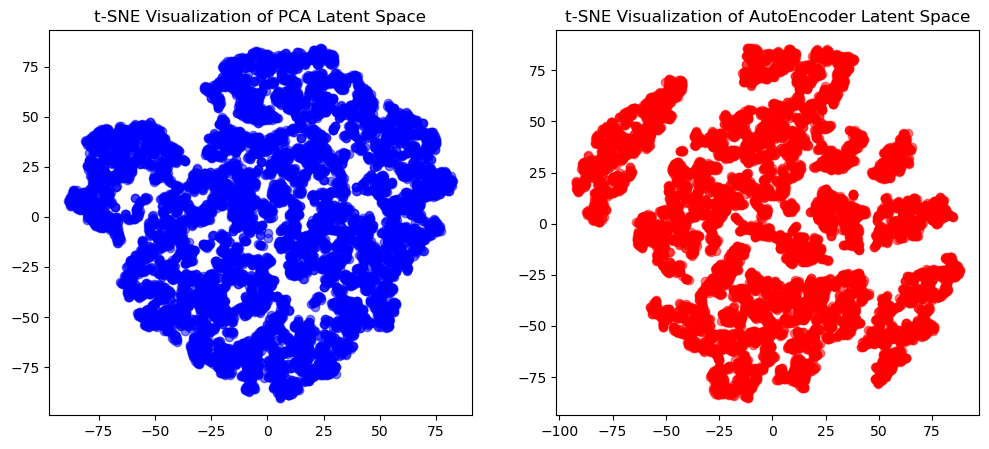

In [75]:
tsne_pca = TSNE(n_components=2, random_state=42).fit_transform(test_pca)
tsne_ae = TSNE(n_components=2, random_state=42).fit_transform(test_ae)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(tsne_pca[:, 0], tsne_pca[:, 1], c='blue', alpha=0.5)
plt.title("t-SNE Visualization of PCA Latent Space")

plt.subplot(1, 2, 2)
plt.scatter(tsne_ae[:, 0], tsne_ae[:, 1], c='red', alpha=0.5)
plt.title("t-SNE Visualization of AutoEncoder Latent Space")

plt.show()

### Reconstruction of latent samples

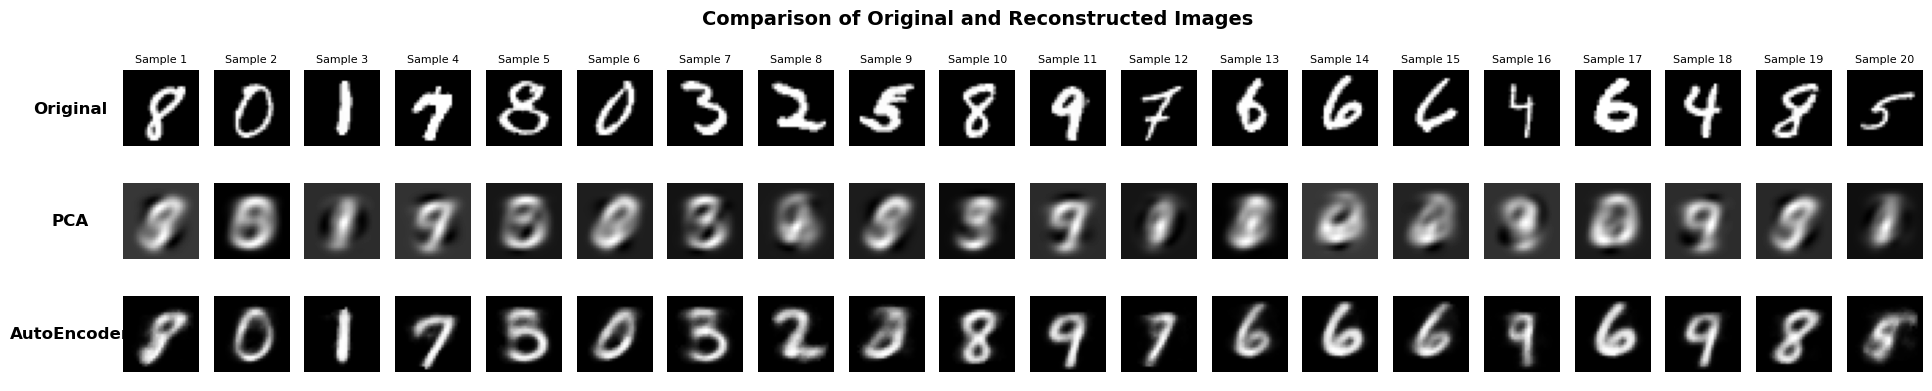

In [76]:
num_samples = 20
random_samples = np.random.randint(0, test_images.shape[0], num_samples)

original_images = test_images[random_samples].reshape(-1, 28, 28)
pca_recon_images = test_pca_recon[random_samples].reshape(-1, 28, 28)
ae_recon_images = test_ae_recon[random_samples].reshape(-1, 28, 28)

def plot_images(original, pca, autoencoder, num_samples=10):
    fig, axes = plt.subplots(3, num_samples+1, figsize=(num_samples+1, 4))
    
    row_titles = ["Original", "PCA", "AutoEncoder"]
    
    for row in range(3):
        axes[row, 0].axis('off')
        axes[row, 0].text(0.5, 0.5, row_titles[row], ha='center', va='center',
                          fontsize=12, fontweight='bold')
    
    for i in range(num_samples):
        axes[0, i+1].imshow(original[i], cmap='gray')
        axes[0, i+1].axis('off')
        axes[1, i+1].imshow(pca[i], cmap='gray')
        axes[1, i+1].axis('off')
        axes[2, i+1].imshow(autoencoder[i], cmap='gray')
        axes[2, i+1].axis('off')
        
        axes[0, i+1].set_title(f"Sample {i+1}", fontsize=8)
    
    fig.suptitle("Comparison of Original and Reconstructed Images", fontsize=14, fontweight='bold')
    
    plt.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.05)
    plt.show()

plot_images(original_images, pca_recon_images, ae_recon_images, num_samples=20)

### Compression Ratio

In [1]:
original_size = 784 
compressed_size = 4
compression_ratio = original_size / compressed_size

print(f"Compression Ratio: {compression_ratio:.4f}")


Compression Ratio: 196.0000


### Compresion Ratio is 196

Sample 0 Difference Matrix:
[[2.49211611e-14 1.93047210e-11 7.24692355e-12 3.82199584e-11
  2.14180258e-12 6.21682935e-13 3.21410455e-12 1.17756846e-12
  1.02772114e-11 1.21413318e-12 8.92287925e-13 1.94388149e-14
  1.07913938e-12 3.08500751e-12 9.98181098e-14 2.34605933e-12
  1.14087505e-12 7.46676158e-12 2.11557031e-12 3.92539690e-12
  4.02461522e-15 8.84444536e-13 6.74021331e-13 1.17020827e-13
  7.20319475e-13 1.08356197e-11 2.49952598e-12 9.39658182e-13]
 [5.27233964e-14 2.49656090e-13 1.96229057e-11 5.12180452e-15
  4.23106781e-13 1.64523375e-12 2.10757755e-14 2.86539802e-12
  3.10892940e-13 8.32702234e-13 9.70282604e-11 2.58034184e-11
  4.47420929e-14 1.38100989e-11 2.93590694e-12 4.50378103e-11
  4.21531808e-14 4.76828429e-12 2.93215051e-13 1.85251532e-12
  9.08368259e-12 2.38047293e-13 1.12610463e-12 7.92918357e-13
  3.12319506e-12 4.74418074e-12 2.27806218e-13 3.61206392e-14]
 [3.77327157e-14 4.55715457e-12 2.16450379e-13 1.52739854e-13
  3.91464508e-12 1.97784497e-13 1.029669

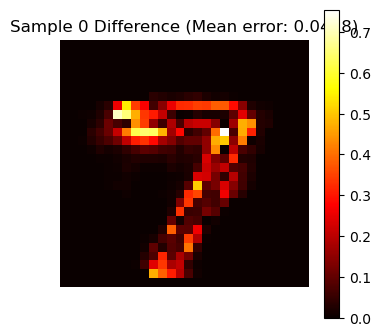

Sample 1 Difference Matrix:
[[1.19447974e-09 4.92951591e-09 1.75572055e-08 1.12727108e-07
  2.50967158e-09 2.49460497e-09 5.59182123e-09 8.91721541e-09
  6.88397694e-09 9.23756849e-10 5.23541566e-09 8.67199361e-08
  1.00804705e-07 6.38920428e-09 5.94329364e-10 4.39021797e-09
  1.05933138e-08 5.25007806e-08 3.22197948e-08 7.62770558e-09
  7.57259144e-09 2.69093275e-10 2.56337298e-08 3.54213525e-09
  9.10185438e-09 2.02143102e-08 7.15873938e-08 1.93553618e-09]
 [1.07368043e-08 1.30722411e-08 7.38382377e-09 3.23290461e-09
  2.99749670e-09 6.19175751e-08 1.44774026e-09 6.85900614e-10
  8.09077161e-09 1.69525585e-08 9.36564604e-09 4.27768621e-09
  5.38159384e-09 2.83038997e-08 2.81901684e-08 6.09363553e-07
  1.00685282e-09 2.65486011e-09 2.97007876e-08 1.92502210e-08
  1.19689830e-07 1.97635952e-09 1.18762422e-08 1.33457654e-08
  3.44643603e-08 7.58592034e-09 1.30222644e-09 7.72286057e-09]
 [1.19363031e-09 6.47851550e-09 6.63418565e-09 1.13057261e-08
  3.58369903e-08 2.62608939e-08 4.440996

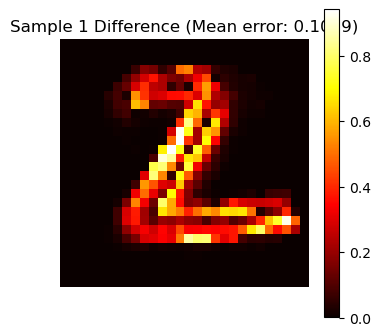

Sample 2 Difference Matrix:
[[5.80324788e-10 1.06509122e-08 2.51055710e-09 7.12591852e-09
  1.60610392e-09 3.05493103e-10 2.20492713e-09 3.32559269e-09
  5.72011638e-09 2.48056553e-09 5.42347833e-10 9.46808673e-11
  1.35636047e-09 1.53498902e-09 5.31276689e-11 2.42453191e-09
  2.39933562e-09 5.52699086e-09 9.38861167e-09 3.35757511e-09
  1.94657165e-10 3.43308959e-09 8.20987989e-09 1.02333815e-10
  2.05175446e-10 4.76438222e-09 1.35688827e-09 2.78973927e-10]
 [2.27571198e-10 2.55474686e-09 2.33284170e-09 7.79045328e-10
  3.71077391e-09 2.09976658e-09 2.35760699e-11 2.45538168e-09
  6.75613288e-10 2.25648034e-08 8.34668890e-10 2.57080446e-09
  7.24717647e-11 4.94917751e-09 3.06970023e-08 1.82563667e-07
  5.30203170e-09 4.36280700e-08 2.48767740e-09 4.53367566e-09
  2.48960941e-09 1.44179890e-09 3.89648269e-09 2.26573977e-08
  1.37790146e-09 7.26399829e-09 2.22130514e-09 7.69879549e-10]
 [2.31640845e-10 4.11812051e-09 4.27406510e-09 6.15380524e-10
  5.72917602e-10 4.57635679e-10 1.963730

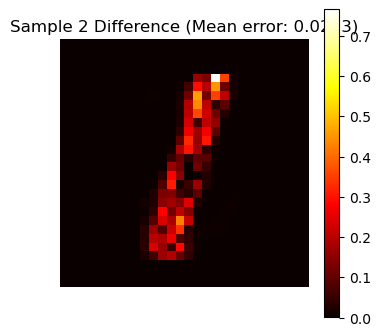

Sample 3 Difference Matrix:
[[2.94695204e-13 1.46540228e-11 5.25850014e-14 2.42296092e-12
  3.67201895e-14 2.45154747e-14 1.56414459e-13 1.47892291e-14
  3.63807725e-13 4.96166701e-15 1.26190887e-12 4.14925323e-14
  8.24516355e-15 3.71512462e-15 5.45120210e-13 2.27790172e-13
  5.84703672e-13 2.17740102e-14 2.73776038e-13 1.71650216e-12
  1.74597478e-13 6.24170908e-13 5.55772842e-14 1.64948730e-13
  8.34727727e-14 1.21076369e-12 1.56876966e-13 2.55003402e-13]
 [2.77572453e-12 3.56194295e-14 1.62644912e-14 3.18017631e-15
  3.90234821e-14 2.98406265e-13 8.35800342e-13 1.88287916e-13
  4.58687385e-12 1.20674236e-13 2.05563336e-13 1.67878325e-13
  1.01077746e-14 3.14129083e-12 1.43550956e-13 3.62453166e-12
  1.23457204e-14 6.01186759e-15 2.85644616e-14 8.47889413e-13
  2.35762690e-13 8.15287101e-14 2.65130230e-13 2.10999075e-14
  2.43190478e-13 1.72644576e-14 2.20661688e-14 2.80507886e-14]
 [5.63783937e-13 2.09087820e-13 9.07227513e-15 2.06730032e-12
  2.69788207e-13 1.71305068e-13 1.014665

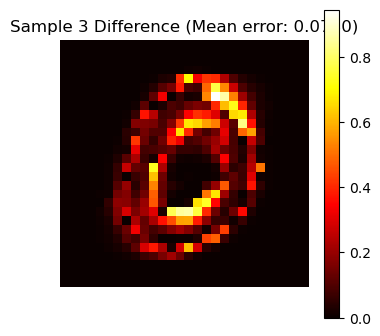

Sample 4 Difference Matrix:
[[1.85244753e-09 3.00434984e-08 3.06185342e-07 1.29491852e-07
  1.68970029e-08 7.96858846e-09 4.90328098e-08 2.25537029e-08
  3.69243267e-08 6.96140479e-09 8.24680857e-09 1.88213711e-08
  4.11848049e-07 6.62280968e-08 1.02580939e-08 9.72789351e-08
  8.60622773e-09 1.79225559e-08 6.46915836e-08 8.77315820e-09
  6.79740753e-09 5.41001910e-09 1.62267693e-08 1.64675029e-08
  8.77183979e-08 9.76291261e-08 4.58146161e-08 4.17079988e-08]
 [2.03616168e-09 1.50125761e-08 2.04704705e-07 2.32201565e-08
  1.44674166e-08 1.62536608e-07 3.64166866e-08 3.05177181e-08
  4.10857410e-08 4.66182719e-08 6.95422813e-08 2.29483248e-07
  6.64420554e-08 1.15020134e-06 6.42649596e-08 8.46315913e-07
  9.78695969e-09 1.00800817e-08 1.74971628e-08 6.29558841e-08
  9.92589122e-08 2.02432147e-07 2.90865732e-08 1.53243818e-07
  8.91163765e-09 7.84306025e-08 3.11791588e-08 1.05284158e-07]
 [1.23129755e-08 2.83541510e-08 8.96537600e-09 4.20614263e-08
  1.25412569e-07 1.67657319e-08 2.233365

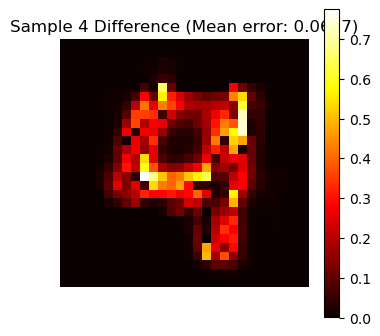

In [87]:
test_images_reshaped = test_images.reshape(-1, 28, 28)
ae_recon_images_reshaped = test_ae_recon.reshape(-1, 28, 28)

num_samples_to_show = 5

for i in range(num_samples_to_show):
    orig_img = test_images_reshaped[i]
    recon_img = ae_recon_images_reshaped[i]
    
    diff_img = np.abs(orig_img - recon_img)
    
    mean_error = np.mean(diff_img)
    
    print(f"Sample {i} Difference Matrix:")
    print(diff_img)
    print(f"Mean Absolute Error for sample {i}: {mean_error:.4f}\n")
    
    plt.figure(figsize=(4, 4))
    plt.imshow(diff_img, cmap='hot')
    plt.title(f"Sample {i} Difference (Mean error: {mean_error:.4f})")
    plt.colorbar()
    plt.axis('off')
    plt.show()


----------------------

## Q2 - Train an autoencoder model for anomaly classification

In [1]:
import os
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from PIL import Image

In [3]:
dataset_path = "/home/rzeta/sem6/dl/lab/lab_5/isic2020"
train_csv_path = os.path.join(dataset_path, "train.csv")

train_df = pd.read_csv(train_csv_path)

non_melanoma_df = train_df[train_df['target'] == 0]

train_image_paths = [os.path.join(dataset_path, "train", img + ".jpg") for img in non_melanoma_df['image_name']]

print(f"Total Non-Melanoma Images: {len(train_image_paths)}")


Total Non-Melanoma Images: 29978


In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor(),  # Convert to Tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1,1]
])

class ISICDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')  # Load image
        if self.transform:
            img = self.transform(img)
        return img  # Return only image as Tensor


In [5]:
train_dataset = ISICDataset(train_image_paths, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Total Training Batches: {len(train_loader)}")


Total Training Batches: 937


In [6]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # 64x64x16
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16x64
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16*16*64, 4),  # 4D latent space
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 16*16*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 16, 16)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64x64x16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 128x128x3
            nn.Tanh()  # Output in [-1,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

autoencoder = AutoEncoder().cuda()

criterion = nn.MSELoss()  # Minimize reconstruction error
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)


#### **Latent dimension is 4D**

### Training model

In [7]:
num_epochs = 20

for epoch in range(num_epochs):
    total_loss = 0
    for batch in train_loader:
        images = batch.cuda()
        optimizer.zero_grad()

        # Forward pass
        outputs = autoencoder(images)
        loss = criterion(outputs, images)

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/20], Loss: 0.0377
Epoch [2/20], Loss: 0.0208
Epoch [3/20], Loss: 0.0203
Epoch [4/20], Loss: 0.0197
Epoch [5/20], Loss: 0.0192
Epoch [6/20], Loss: 0.0189
Epoch [7/20], Loss: 0.0186
Epoch [8/20], Loss: 0.0184
Epoch [9/20], Loss: 0.0183
Epoch [10/20], Loss: 0.0182
Epoch [11/20], Loss: 0.0181
Epoch [12/20], Loss: 0.0180
Epoch [13/20], Loss: 0.0179
Epoch [14/20], Loss: 0.0178
Epoch [15/20], Loss: 0.0177
Epoch [16/20], Loss: 0.0177
Epoch [17/20], Loss: 0.0176
Epoch [18/20], Loss: 0.0176
Epoch [19/20], Loss: 0.0175
Epoch [20/20], Loss: 0.0174


### Reconstruction Error

In [8]:
test_csv_path = os.path.join(dataset_path, "test.csv")
test_df = pd.read_csv(test_csv_path)

test_image_paths = [os.path.join(dataset_path, "test", img + ".jpg") for img in test_df['image_name']]

test_dataset = ISICDataset(test_image_paths, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

reconstruction_errors = []
autoencoder.eval()

with torch.no_grad():
    for img in test_loader:
        img = img.cuda()
        reconstructed_img = autoencoder(img)
        loss = criterion(reconstructed_img, img)  # MSE Loss
        reconstruction_errors.append(loss.item())

reconstruction_errors = np.array(reconstruction_errors)


### Threshold Value of Reconstruction error

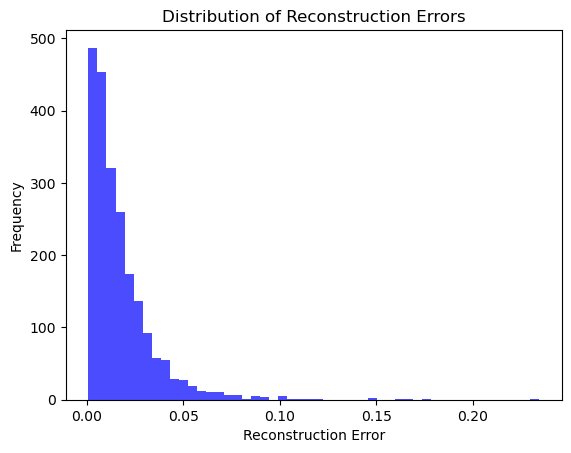

Threshold for anomaly detection: 0.0486


In [9]:
plt.hist(reconstruction_errors, bins=50, color='blue', alpha=0.7)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors")
plt.show()

threshold = np.percentile(reconstruction_errors, 95)
print(f"Threshold for anomaly detection: {threshold:.4f}")


### tSNE Plot

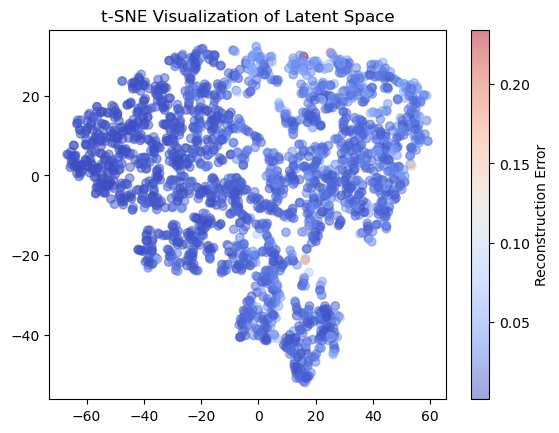

In [10]:
latent_vectors = []

with torch.no_grad():
    for img in test_loader:
        img = img.cuda()
        latent_vector = autoencoder.encoder(img).cpu().numpy()
        latent_vectors.append(latent_vector)

latent_vectors = np.array(latent_vectors).squeeze()

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(latent_vectors)

plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=reconstruction_errors, cmap='coolwarm', alpha=0.5)
plt.colorbar(label="Reconstruction Error")
plt.title("t-SNE Visualization of Latent Space")
plt.show()


---------

## Q3 - Training a VAE model for generating new data similar to training set.

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1,1]
])

# Load dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print("FashionMNIST dataset loaded successfully!")

FashionMNIST dataset loaded successfully!


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        # Latent space
        self.mu_layer = nn.Linear(256, latent_dim)  
        self.log_var_layer = nn.Linear(256, latent_dim)  
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Tanh()  # Output in [-1,1]
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std) 
        return mu + eps * std

    def forward(self, x):
        # Encode
        x = self.encoder(x)
        mu = self.mu_layer(x)
        log_var = self.log_var_layer(x)
        
        # Reparameterization
        z = self.reparameterize(mu, log_var)
        
        # Decode
        out = self.decoder(z)
        return out, mu, log_var


In [27]:
def vae_loss(reconstructed_x, x, mu, log_var):
    reconstruction_loss = nn.functional.mse_loss(reconstructed_x, x, reduction="sum")
    
    # KL Divergence Loss
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    return reconstruction_loss + kl_divergence


### Training the model on fashionMNIST dataset

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

num_epochs = 50

for epoch in range(num_epochs):
    total_loss = 0
    for batch, _ in train_loader:
        batch = batch.view(-1, 28 * 28).to(device)  # Flatten images

        optimizer.zero_grad()
        
        # Forward pass
        reconstructed_batch, mu, log_var = vae(batch)
        
        # Compute loss
        loss = vae_loss(reconstructed_batch, batch, mu, log_var)
        
        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch [1/50], Loss: 107.0744
Epoch [2/50], Loss: 73.7965
Epoch [3/50], Loss: 69.0089
Epoch [4/50], Loss: 66.3849
Epoch [5/50], Loss: 64.7719
Epoch [6/50], Loss: 63.6786
Epoch [7/50], Loss: 62.9058
Epoch [8/50], Loss: 62.2237
Epoch [9/50], Loss: 61.7606
Epoch [10/50], Loss: 61.2676
Epoch [11/50], Loss: 60.8295
Epoch [12/50], Loss: 60.6014
Epoch [13/50], Loss: 60.2281
Epoch [14/50], Loss: 59.9595
Epoch [15/50], Loss: 59.7392
Epoch [16/50], Loss: 59.5357
Epoch [17/50], Loss: 59.3170
Epoch [18/50], Loss: 59.1249
Epoch [19/50], Loss: 58.9872
Epoch [20/50], Loss: 58.7930
Epoch [21/50], Loss: 58.6223
Epoch [22/50], Loss: 58.5526
Epoch [23/50], Loss: 58.3677
Epoch [24/50], Loss: 58.2525
Epoch [25/50], Loss: 58.1731
Epoch [26/50], Loss: 58.1185
Epoch [27/50], Loss: 57.9471
Epoch [28/50], Loss: 57.8676
Epoch [29/50], Loss: 57.7841
Epoch [30/50], Loss: 57.6450
Epoch [31/50], Loss: 57.6242
Epoch [32/50], Loss: 57.4949
Epoch [33/50], Loss: 57.4457
Epoch [34/50], Loss: 57.4151
Epoch [35/50], Loss: 5

In [29]:
vae.eval()

z_samples = torch.randn(30, 10).to(device)

with torch.no_grad():
    generated_images = vae.decoder(z_samples).cpu().numpy()

generated_images = generated_images.reshape(-1, 28, 28)


### Generating 30 new samples using the learned model and ploting them

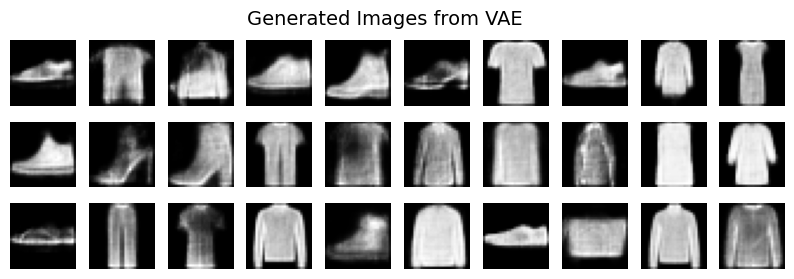

In [30]:
fig, axes = plt.subplots(3, 10, figsize=(10, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i], cmap="gray")
    ax.axis("off")

plt.suptitle("Generated Images from VAE", fontsize=14)
plt.show()


-------------

--------------------